<a href="https://colab.research.google.com/github/nguyenvuonghongvy/Image-Captioning-Flickr8k/blob/main/BaoCao_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("adityajn105/flickr8k")

Using Colab cache for faster access to the 'flickr8k' dataset.


Thư mục chứa dữ liệu: /kaggle/input/flickr8k

Các file có trong bộ dữ liệu:
['captions.txt', 'Images']

--- 5 dòng đầu tiên của file captions.txt ---


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...



--- Hiển thị thử bức ảnh đầu tiên ---


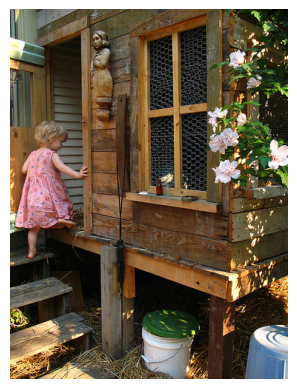

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. In ra đường dẫn xem bộ dữ liệu nằm ở đâu
print("Thư mục chứa dữ liệu:", path)

# 2. Xem bên trong thư mục này có những file/thư mục con nào
print("\nCác file có trong bộ dữ liệu:")
print(os.listdir(path))

# 3. Tạo đường dẫn cụ thể tới file văn bản (captions.txt) và thư mục ảnh (Images)
captions_file = os.path.join(path, "captions.txt")
images_dir = os.path.join(path, "Images")

# 4. Đọc thử 5 dòng đầu tiên của file captions.txt bằng thư viện pandas
print("\n--- 5 dòng đầu tiên của file captions.txt ---")
df = pd.read_csv(captions_file)
display(df.head()) # Lệnh display giúp hiển thị bảng rất đẹp trên Colab

# 5. Load và hiển thị thử bức ảnh đầu tiên trong danh sách
print("\n--- Hiển thị thử bức ảnh đầu tiên ---")
first_image_name = df['image'].iloc[0] # Lấy tên ảnh ở dòng đầu tiên
first_image_path = os.path.join(images_dir, first_image_name)

img = Image.open(first_image_path)
plt.imshow(img)
plt.axis('off') # Ẩn trục tọa độ
plt.show()

In [4]:
import torch
from collections import Counter

class Vocabulary:
    def __init__(self, freq_threshold=5):
        # 1. Thiết lập các token (ký hiệu) đặc biệt bắt buộc phải có
        # <PAD>: Dùng để làm cho các câu dài bằng nhau
        # <SOS>: Start Of Sentence (Bắt đầu câu)
        # <EOS>: End Of Sentence (Kết thúc câu)
        # <UNK>: Unknown (Từ hiếm gặp hoặc chưa từng thấy)
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold # Bỏ qua các từ xuất hiện quá ít (ít hơn 5 lần)

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize_en(text):
        # Viết thường tất cả các chữ và tách từ bằng khoảng trắng
        return text.lower().split()

    def build_vocabulary(self, sentence_list):
        # Xây dựng từ điển dựa trên tần suất xuất hiện của từ
        frequencies = Counter()
        idx = 4 # Bắt đầu từ số 4 (do 0,1,2,3 đã gán cho token đặc biệt ở trên)

        for sentence in sentence_list:
            for word in self.tokenize_en(sentence):
                frequencies[word] += 1

                # Nếu từ xuất hiện đủ nhiều, ta sẽ thêm nó vào từ điển
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        # Hàm biến 1 câu văn bản bình thường thành 1 mảng các con số
        tokenized_text = self.tokenize_en(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

# ==========================================
# CHẠY THỬ XEM TỪ ĐIỂN HOẠT ĐỘNG THẾ NÀO
# ==========================================

# 1. Lấy toàn bộ cột caption từ bảng dữ liệu df (đã chạy ở bước trước)
captions_list = df['caption'].astype(str).tolist()

# 2. Khởi tạo từ điển và xây dựng nó
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(captions_list)

print(f"Tổng số từ vựng (Vocabulary Size) mô hình cần học là: {len(vocab)} từ")

# 3. Thử chuyển một câu thành các con số
cau_thu_nghiem = "a little girl in a pink dress"
so_hoa = vocab.numericalize(cau_thu_nghiem)

print(f"\nCâu gốc: '{cau_thu_nghiem}'")
print(f"Sau khi biến thành số: {so_hoa}")

Tổng số từ vựng (Vocabulary Size) mô hình cần học là: 3005 từ

Câu gốc: 'a little girl in a pink dress'
Sau khi biến thành số: [4, 9, 7, 8, 4, 190, 148]


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.nn.utils.rnn import pad_sequence

# 1. Tạo Class Dataset (Đọc từng cặp Ảnh - Chữ)
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform

        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        # Khởi tạo và xây dựng từ điển ngay bên trong Dataset
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img_path = os.path.join(self.root_dir, img_id)

        # Đọc ảnh
        img = Image.open(img_path).convert("RGB")

        # Thu nhỏ, biến đổi ảnh (Transform)
        if self.transform is not None:
            img = self.transform(img)

        # Số hóa caption và kẹp thêm 2 từ <SOS> (Bắt đầu) và <EOS> (Kết thúc)
        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

# 2. Tạo Class Collate để đệm (pad) các câu cho dài bằng nhau
class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # Gom các bức ảnh lại với nhau
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        # Gom các câu lại, lấy độ dài của câu dài nhất làm mốc
        # Câu nào ngắn hơn sẽ được chèn thêm số 0 (Pad) vào cuối
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        return imgs, targets

# ==========================================
# KHỞI TẠO DATALOADER ĐỂ DÙNG THỰC TẾ
# ==========================================

# A. Thiết lập chuẩn hóa ảnh (Size 224x224 dành cho mô hình ResNet, ViT...)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# B. Khởi tạo Dataset
dataset = FlickrDataset(
    root_dir=images_dir,
    captions_file=captions_file,
    transform=transform
)

# C. Lấy ra mã số của token <PAD> (Thường là số 0)
pad_idx = dataset.vocab.stoi["<PAD>"]

# D. Tạo DataLoader (Batch size = 32 theo phổ biến)
dataloader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True, # Trộn ngẫu nhiên dữ liệu
    collate_fn=MyCollate(pad_idx=pad_idx)
)

print(f"Đã tạo DataLoader thành công!")
print(f"Tổng số Batch trong 1 Epoch là: {len(dataloader)}")

Đã tạo DataLoader thành công!
Tổng số Batch trong 1 Epoch là: 1265


In [6]:
import torch.nn as nn
import torchvision.models as models

class ResNet50Encoder(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(ResNet50Encoder, self).__init__()

        # 1. Tải mô hình ResNet-50 đã được huấn luyện sẵn (Pre-trained)
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # 2. Bỏ đi lớp Linear cuối cùng của ResNet (vì lớp đó dùng để phân loại chó mèo)
        # Ở đây chúng ta không phân loại, chúng ta chỉ cần "Trích xuất đặc trưng"
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        # 3. Thêm một lớp Linear mới để ép kích thước đặc trưng về đúng kích thước embed_size
        # (Để sau đó đẩy sang Transformer Decoder)
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # Chống học vẹt (overfitting)

        # 4. Cấu hình: Đóng băng (Freeze) hay Huấn luyện lại (Fine-tune)
        # Theo phiếu báo cáo, bạn hãy tích vào ô "Đóng băng" nhé (train_CNN = False)
        for name, param in self.resnet.named_parameters():
            if "layer4" in name:
                param.requires_grad = train_CNN
            else:
                param.requires_grad = False

    def forward(self, images):
        # Đưa ảnh qua ResNet
        features = self.resnet(images)

        # Trải phẳng kết quả: [batch_size, 2048, 1, 1] thành [batch_size, 2048]
        features = features.view(features.size(0), -1)

        # Đưa qua lớp Linear để nén lại
        features = self.dropout(self.relu(self.fc(features)))
        return features

# ==========================================
# KHỞI TẠO MÔ HÌNH VÀ CHẠY THỬ
# ==========================================

# Kích thước d_model (nhớ ghi số 256 này vào phiếu báo cáo nhé)
embed_size = 256

# Khởi tạo Encoder
encoder = ResNet50Encoder(embed_size=embed_size, train_CNN=False)
print("Khởi tạo Visual Encoder (ResNet-50) thành công!")

# Thử đưa 1 batch ảnh từ DataLoader lúc nãy qua Encoder xem kết quả thế nào
images, captions = next(iter(dataloader))
features = encoder(images)

print(f"Kích thước 1 batch Ảnh đầu vào: {images.shape}")
print(f"Kích thước Đặc trưng xuất ra: {features.shape}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Khởi tạo Visual Encoder (ResNet-50) thành công!
Kích thước 1 batch Ảnh đầu vào: torch.Size([32, 3, 224, 224])
Kích thước Đặc trưng xuất ra: torch.Size([32, 256])


In [7]:
import math

# 1. Lớp Positional Encoding: Giúp mô hình nhận biết thứ tự các từ
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=100):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

# 2. Xây dựng Transformer Decoder
class TransformerDecoderModel(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, num_layers, dropout=0.1):
        super(TransformerDecoderModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, dropout)

        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_size, nhead=num_heads, dropout=dropout)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.embed_size = embed_size

    def generate_square_subsequent_mask(self, sz):
        # Tạo mặt nạ tam giác để che các từ trong tương lai (không cho nhìn trộm)
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, features, captions):
        # Đảo chiều để khớp với yêu cầu của PyTorch: (Thời_gian, Batch, Đặc_trưng)
        captions = captions.transpose(0, 1)
        seq_len = captions.shape[0]

        # Nhúng từ vựng + vị trí
        embeddings = self.embedding(captions) * math.sqrt(self.embed_size)
        embeddings = self.pos_encoder(embeddings)

        # Đưa đặc trưng ảnh từ ResNet (bối cảnh) vào khớp kích thước
        features = features.unsqueeze(0)

        # Đưa qua Transformer
        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(captions.device)
        output = self.transformer_decoder(tgt=embeddings, memory=features, tgt_mask=tgt_mask)

        # Dự đoán từ
        predictions = self.fc_out(output)

        # Đổi lại shape về (Batch, Thời_gian, Từ_vựng) cho dễ tính Loss
        return predictions.transpose(0, 1)

# ==========================================
# KHỞI TẠO MÔ HÌNH VÀ CHẠY THỬ
# ==========================================

vocab_size = len(dataset.vocab) # 3005
num_heads = 8   # Số lượng Attention Head
num_layers = 3  # Số lớp (layer) của Decoder
dropout = 0.1   # Tỷ lệ Dropout

# Khởi tạo Decoder
decoder = TransformerDecoderModel(
    vocab_size=vocab_size,
    embed_size=embed_size, # Là số 256 ở ô code trước truyền sang
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
)

print("Khởi tạo Transformer Decoder thành công!")

# Nối Encoder và Decoder chạy thử với nhau (Bỏ từ cuối cùng <EOS> đi)
outputs = decoder(features, captions[:, :-1])

print(f"Kích thước đầu ra cuối cùng của mô hình: {outputs.shape}")

Khởi tạo Transformer Decoder thành công!
Kích thước đầu ra cuối cùng của mô hình: torch.Size([32, 17, 3005])


In [8]:
import torch.optim as optim

# ==========================================
# CHUẨN BỊ CHO HUẤN LUYỆN
# ==========================================

# 1. Chuyển mô hình sang GPU (Card đồ họa) để chạy nhanh gấp hàng chục lần
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# Nhắc nhở nếu bạn đang quên bật GPU trên Colab
if device.type == "cpu":
    print("⚠️ CẢNH BÁO: Bạn đang dùng CPU, huấn luyện sẽ cực kỳ chậm! Hãy vào menu Runtime (Thời gian chạy) trên cùng -> Change runtime type (Thay đổi loại thời gian chạy) -> Chọn T4 GPU.")

encoder = encoder.to(device)
decoder = decoder.to(device)

# 2. Khai báo hàm Mất mát (Loss) và Tối ưu hóa (Optimizer)
# Bỏ qua token <PAD> khi tính Loss để mô hình không mất công học chữ vô nghĩa này
criterion = nn.CrossEntropyLoss(ignore_index=dataset.vocab.stoi["<PAD>"])

# Gom toàn bộ trọng số của Decoder và lớp cuối của Encoder để tối ưu
# (Vì ResNet ta đã đóng băng ở ô code trước, nên nó sẽ không thay đổi)
params = list(decoder.parameters()) + list(encoder.fc.parameters())

# Tốc độ học (Learning rate). Theo phiếu báo cáo, bạn điền số 3e-4 (hay 0.0003) vào báo cáo nhé
learning_rate = 3e-4
optimizer = optim.Adam(params, lr=learning_rate)

# ==========================================
# VÒNG LẶP HUẤN LUYỆN (CHẠY THỬ 1 EPOCH)
# ==========================================

num_epochs = 1 # Bạn có thể tăng số này lên (ví dụ: 10, 20) sau khi chạy thử thành công

print("\n🚀 Bắt đầu quá trình huấn luyện...")
for epoch in range(num_epochs):
    # Đặt mô hình ở chế độ huấn luyện
    encoder.train()
    decoder.train()

    total_loss = 0

    for batch_idx, (imgs, captions) in enumerate(dataloader):
        # Đưa dữ liệu lên GPU
        imgs = imgs.to(device)
        captions = captions.to(device)

        # Bước 1: Cho ảnh đi qua Encoder để lấy đặc trưng
        features = encoder(imgs)

        # Bước 2: Đưa đặc trưng và câu caption (bỏ từ cuối <EOS>) vào Decoder
        outputs = decoder(features, captions[:, :-1])

        # Bước 3: Tính Loss (Sai số giữa việc AI đoán và câu đáp án thực tế)
        targets = captions[:, 1:] # Đáp án thực tế là dịch dịch sang phải 1 từ
        loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))

        # Bước 4: Cập nhật trọng số (Backpropagation)
        optimizer.zero_grad()
        loss.backward()

        # Cắt bớt gradient để tránh mô hình bị hỏng (thường dùng trong Transformer)
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        # Cứ mỗi 100 batch, in ra màn hình một lần để theo dõi tiến độ
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx}/{len(dataloader)}] | Loss (Sai số): {loss.item():.4f}")

    print(f"✅ Hết Epoch {epoch+1}. Trung bình Training loss: {total_loss / len(dataloader):.4f}")

Đang sử dụng thiết bị: cuda

🚀 Bắt đầu quá trình huấn luyện...
Epoch [1/1] | Batch [0/1265] | Loss (Sai số): 8.1772
Epoch [1/1] | Batch [100/1265] | Loss (Sai số): 4.1687
Epoch [1/1] | Batch [200/1265] | Loss (Sai số): 4.0045
Epoch [1/1] | Batch [300/1265] | Loss (Sai số): 3.5159
Epoch [1/1] | Batch [400/1265] | Loss (Sai số): 3.5473
Epoch [1/1] | Batch [500/1265] | Loss (Sai số): 3.4134
Epoch [1/1] | Batch [600/1265] | Loss (Sai số): 3.4590
Epoch [1/1] | Batch [700/1265] | Loss (Sai số): 2.9242
Epoch [1/1] | Batch [800/1265] | Loss (Sai số): 3.0146
Epoch [1/1] | Batch [900/1265] | Loss (Sai số): 3.2125
Epoch [1/1] | Batch [1000/1265] | Loss (Sai số): 3.1388
Epoch [1/1] | Batch [1100/1265] | Loss (Sai số): 3.3896
Epoch [1/1] | Batch [1200/1265] | Loss (Sai số): 2.7868
✅ Hết Epoch 1. Trung bình Training loss: 3.4043
